1. Loading the Data

In [1]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Data Augmentation
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),           
    transforms.RandomHorizontalFlip(),    
    transforms.RandomRotation(15),        
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Build Loaders
train_set = torchvision.datasets.FGVCAircraft(root='./aircraft_data', split='train', transform=train_transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)

val_set = torchvision.datasets.FGVCAircraft(root='./aircraft_data', split='val', transform=eval_transform)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=32, shuffle=False)

test_set = torchvision.datasets.FGVCAircraft(root='./aircraft_data', split='test', transform=eval_transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=False)

print("Step 1 Complete: Data is ready.")

Using device: cuda
Step 1 Complete: Data is ready.


2. Setting up ResNet-50

In [2]:
# 1. Load a fresh ResNet-50
model = models.resnet50(weights='IMAGENET1K_V1')
num_features = model.fc.in_features

# 2. Add the "Blindfold" (Dropout) to prevent memorization
model.fc = nn.Sequential(
    nn.Dropout(p=0.5), 
    nn.Linear(num_features, 100)
)
model = model.to(device)

# 3. Setup the Scorekeeper and the Pilot
criterion = nn.CrossEntropyLoss()

# 4. Add the "Weight Penalty" (weight_decay) to stop cheating
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# 5. The Navigator
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

print("Step 2 Complete: Strict model is built and ready on the GPU.")

Step 2 Complete: Strict model is built and ready on the GPU.


In [ ]:
# 1. Load the package from the "strict_aircraft_model.pth"
checkpoint = torch.load('strict_aircraft_model.pth')

# 2. Restore the Brain
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

# 3. Restore the Memory (The history lists)
history_train_loss = checkpoint['history_train_loss']
history_train_acc = checkpoint['history_train_acc']
history_val_acc = checkpoint['history_val_acc']

print(f"✅ Recovery Complete: Restored {len(history_train_loss)} epochs of memory.")

3. Training

In [3]:
import time
import copy
import torch

# ==========================================
# 1. MARATHON PARAMETERS & AUTOMATED TRACKERS
# ==========================================
epochs = 25 
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict()) # The Vault

# The Memory Banks (This fixes the graphing issue permanently)
history_train_loss = []
history_train_acc = []
history_val_acc = []

print(f"Starting the Final Automated Marathon: {epochs} Epochs...\n")

for epoch in range(epochs):
    start_time = time.time()
    
    # ==========================================
    # --- A. TRAINING PHASE ---
    # ==========================================
    model.train()
    running_loss = 0.0
    train_correct = 0  
    train_total = 0    
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # Calculate final training metrics for this epoch
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * train_correct / train_total

    # ==========================================
    # --- B. VALIDATION PHASE ---
    # ==========================================
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_acc = 100 * val_correct / val_total
    epoch_time = time.time() - start_time
    
    # ==========================================
    # --- C. SAVE TO MEMORY BANKS ---
    # ==========================================
    history_train_loss.append(epoch_train_loss)
    history_train_acc.append(epoch_train_acc)
    history_val_acc.append(epoch_val_acc)
    
    # ==========================================
    # --- D. LOGGING & THE VAULT ---
    # ==========================================
    print(f"Epoch {epoch + 1:02d}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.3f} | "
          f"Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Acc: {epoch_val_acc:.2f}% | "
          f"Time: {epoch_time:.1f}s")
    
    # Tell the Navigator our current score
    scheduler.step(epoch_val_acc)
    
    # The Vault: Check for a new high score
    if epoch_val_acc > best_val_acc:
        print(f"  --> ⭐ New Highest Validation Accuracy")
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, 'strict_aircraft_model.pth')

# ==========================================
# --- E. MARATHON COMPLETE ---
# ==========================================
print(f"\nMarathon Complete. The highest Validation Accuracy achieved was: {best_val_acc:.2f}%")

# Create the professional Checkpoint Dictionary
checkpoint = {
    'model_state_dict': best_model_wts,
    'history_train_loss': history_train_loss,
    'history_train_acc': history_train_acc,
    'history_val_acc': history_val_acc,
    'best_acc': best_val_acc
}
# Save the entire bundle (Brain + Memory) to the SSD
torch.save(checkpoint, 'strict_aircraft_model.pth')
print("Model weights and training history saved to 'strict_aircraft_model.pth'")

# Reload the absolute best brain back into the model for final testing
model.load_state_dict(best_model_wts)
print("Best model weights have been reloaded")

Starting the Final Automated Marathon: 25 Epochs...

Epoch 01/25 | Train Loss: 4.393 | Train Acc: 5.07% | Val Acc: 16.26% | Time: 97.1s
  --> ⭐ New Highest Validation Accuracy
Epoch 02/25 | Train Loss: 3.404 | Train Acc: 19.14% | Val Acc: 27.27% | Time: 91.9s
  --> ⭐ New Highest Validation Accuracy
Epoch 03/25 | Train Loss: 2.655 | Train Acc: 31.55% | Val Acc: 36.15% | Time: 88.4s
  --> ⭐ New Highest Validation Accuracy
Epoch 04/25 | Train Loss: 2.138 | Train Acc: 41.96% | Val Acc: 46.86% | Time: 87.5s
  --> ⭐ New Highest Validation Accuracy
Epoch 05/25 | Train Loss: 1.780 | Train Acc: 50.42% | Val Acc: 49.80% | Time: 87.6s
  --> ⭐ New Highest Validation Accuracy
Epoch 06/25 | Train Loss: 1.468 | Train Acc: 59.18% | Val Acc: 51.94% | Time: 88.7s
  --> ⭐ New Highest Validation Accuracy
Epoch 07/25 | Train Loss: 1.238 | Train Acc: 64.34% | Val Acc: 59.80% | Time: 87.2s
  --> ⭐ New Highest Validation Accuracy
Epoch 08/25 | Train Loss: 1.003 | Train Acc: 71.15% | Val Acc: 57.67% | Time: 88

4. Testing

In [4]:
# ==========================================
# FINAL EXAM: Unseen Test Set Evaluation
# ==========================================

# 1. Lock the model (crucial when using Dropout so it doesn't randomly blindfold neurons during testing)
model.eval()

test_correct = 0
test_total = 0

# 2. Turn off the gradient engine to save memory and speed up testing
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

# 3. Calculate and print the final score
final_test_acc = 100 * test_correct / test_total
print(f"=====================================")
print(f"FINAL TEST ACCURACY: {final_test_acc:.2f}%")
print(f"=====================================")

FINAL TEST ACCURACY: 72.37%


Generating Automated Learning Curves...


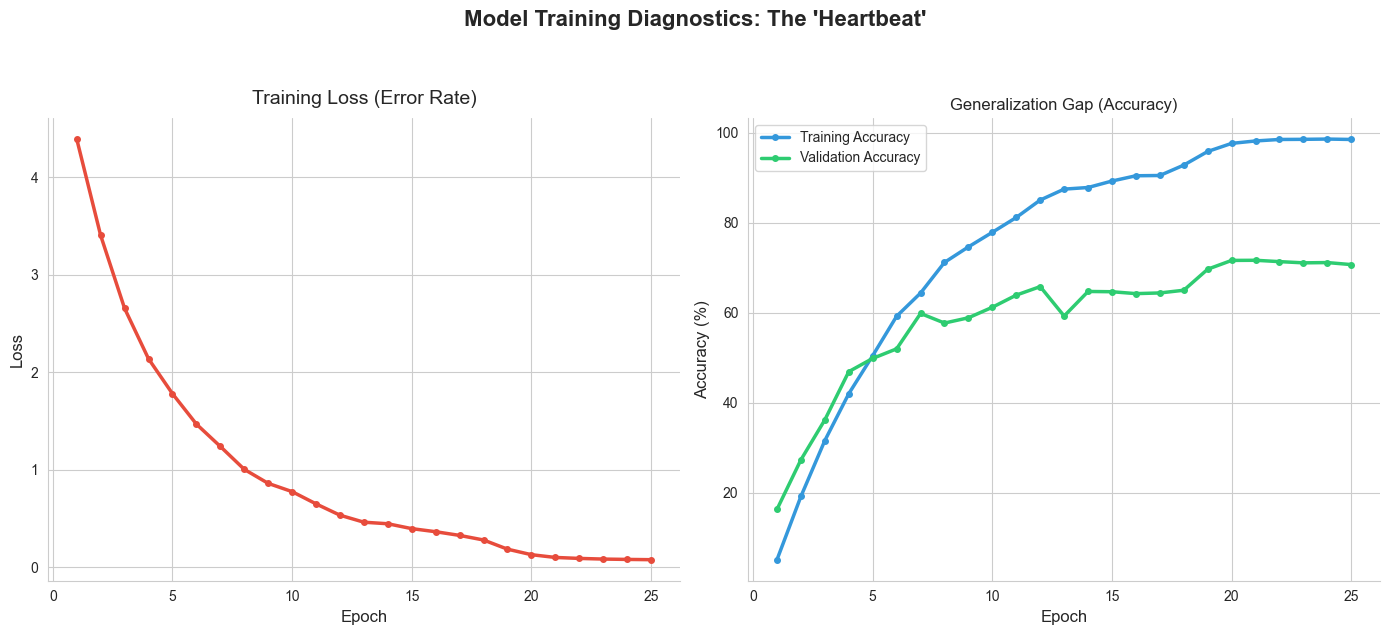

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Automated Learning Curves...")

# Dynamically calculate the number of epochs based on what is in memory
completed_epochs = range(1, len(history_train_loss) + 1)

# Setup the clean, minimalist figure
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Model Training Diagnostics: The 'Heartbeat'", fontsize=16, fontweight='bold', y=1.05)

# --- Panel 1: Training Loss ---
ax1.plot(completed_epochs, history_train_loss, color='#e74c3c', linewidth=2.5, marker='o', markersize=4)
ax1.set_title("Training Loss (Error Rate)", fontsize=14, pad=10)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)

# --- Panel 2: Accuracy Gap ---
ax2.plot(completed_epochs, history_train_acc, label="Training Accuracy", color='#3498db', linewidth=2.5, marker='o', markersize=4)
ax2.plot(completed_epochs, history_val_acc, label="Validation Accuracy", color='#2ecc71', linewidth=2.5, marker='o', markersize=4)

ax2.set_title("Generalization Gap (Accuracy)", fontsize=14, pad=10)
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy (%)", fontsize=12)
ax2.legend(loc="lower right", frameon=True)

sns.despine()
plt.tight_layout()
plt.title("Generalization Gap (Accuracy)")
plt.legend()

plt.savefig('results/learning_curve.png', dpi=300, bbox_inches='tight') 

plt.show()
plt.show()

5. Implemtation of XAI

Generating AI Attention Heatmaps...


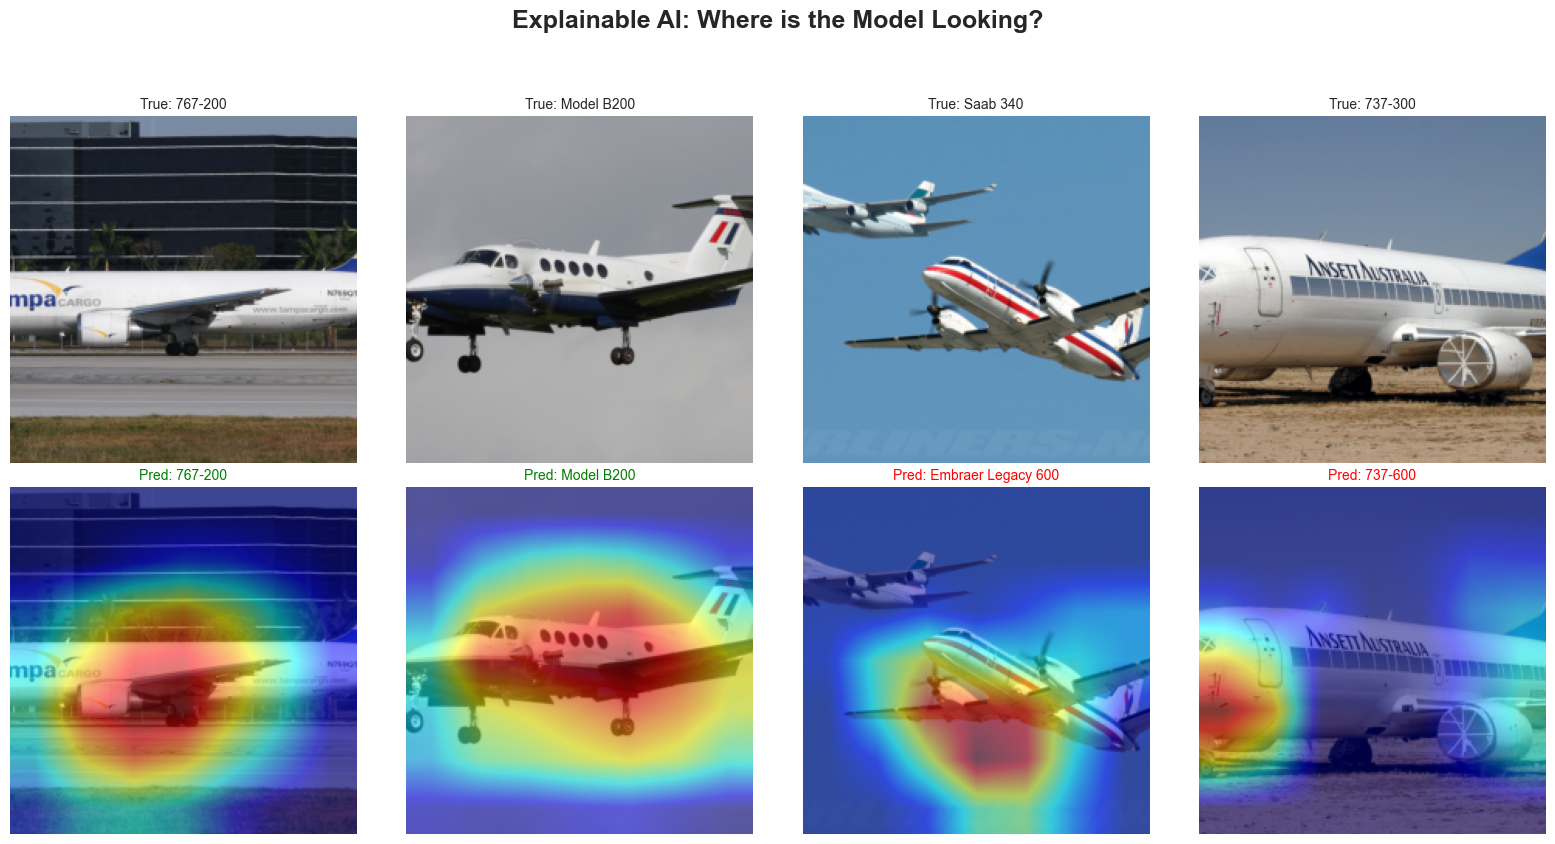

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("Generating AI Attention Heatmaps...")

# 1. Target the final convolutional layer of your ResNet-50
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# 2. Grab a batch of images from the unseen test set
model.eval()
vis_loader = torch.utils.data.DataLoader(test_set, batch_size=4, shuffle=True)
inputs, labels = next(iter(vis_loader))

# 3. Setup a clean, minimalist plot for 4 sample images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Explainable AI: Where is the Model Looking?", fontsize=18, fontweight='bold', y=1.05)

for i in range(4):
    input_tensor = inputs[i:i+1].to(device)
    true_label = labels[i].item()
    
    # Get the model's prediction
    with torch.no_grad():
        output = model(input_tensor)
        predicted_label = torch.argmax(output, dim=1).item()
    
    # Generate the heatmap
    targets = [ClassifierOutputTarget(predicted_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    # De-normalize the image for human viewing
    img_np = input_tensor[0].cpu().numpy().transpose((1, 2, 0))
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    
    # Overlay heatmap
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    
    # Plot Original
    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f"True: {test_set.classes[true_label]}", fontsize=10)
    axes[0, i].axis('off')
    
    # Plot Heatmap
    axes[1, i].imshow(visualization)
    color = "green" if true_label == predicted_label else "red"
    axes[1, i].set_title(f"Pred: {test_set.classes[predicted_label]}", fontsize=10, color=color)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('results/gradcam_sample.png', dpi=300, bbox_inches='tight')
plt.show()

Running full test set to generate Confusion Matrix... 


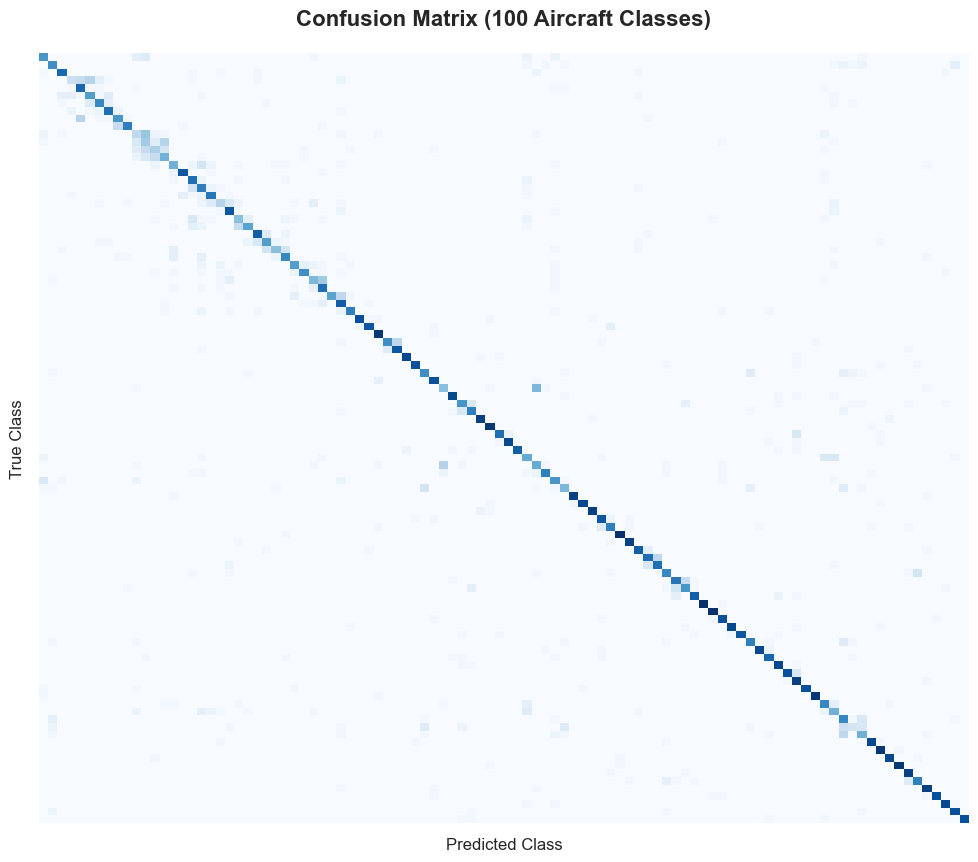


--- FORENSIC ANALYSIS: TOP 5 CONFUSED AIRCRAFT PAIRS ---
The model saw a [C-47] but guessed [DC-3] - 15 times.
The model saw a [747-100] but guessed [747-200] - 13 times.
The model saw a [A340-200] but guessed [A340-300] - 12 times.
The model saw a [737-800] but guessed [737-400] - 10 times.
The model saw a [737-300] but guessed [737-500] - 10 times.


In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

print("Running full test set to generate Confusion Matrix... ")

all_preds = []
all_labels = []

# 1. Gather every single prediction from the test set
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Calculate the 100x100 Matrix
cm = confusion_matrix(all_labels, all_preds)

# 3. Plot the Matrix (Minimalist Style)
plt.figure(figsize=(12, 10))
sns.set_style("white") # Clean background
# We turn off annotations (annot=False) because 10,000 numbers won't fit on the screen
sns.heatmap(cm, cmap="Blues", cbar=False, annot=False, xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix (100 Aircraft Classes)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Predicted Class", fontsize=12, labelpad=10)
plt.ylabel("True Class", fontsize=12, labelpad=10)
plt.savefig('results/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Deep Analysis: Find the Top 5 Mistakes
print("\n--- FORENSIC ANALYSIS: TOP 5 CONFUSED AIRCRAFT PAIRS ---")
errors = []
for i in range(100):
    for j in range(100):
        if i != j and cm[i, j] > 0:
            errors.append({
                'True': test_set.classes[i], 
                'Predicted': test_set.classes[j], 
                'Count': cm[i, j]
            })

# Sort the errors by frequency
errors_df = pd.DataFrame(errors).sort_values(by='Count', ascending=False)

for index, row in errors_df.head(5).iterrows():
    print(f"The model saw a [{row['True']}] but guessed [{row['Predicted']}] - {row['Count']} times.")

Generating Professional Confidence Grid...


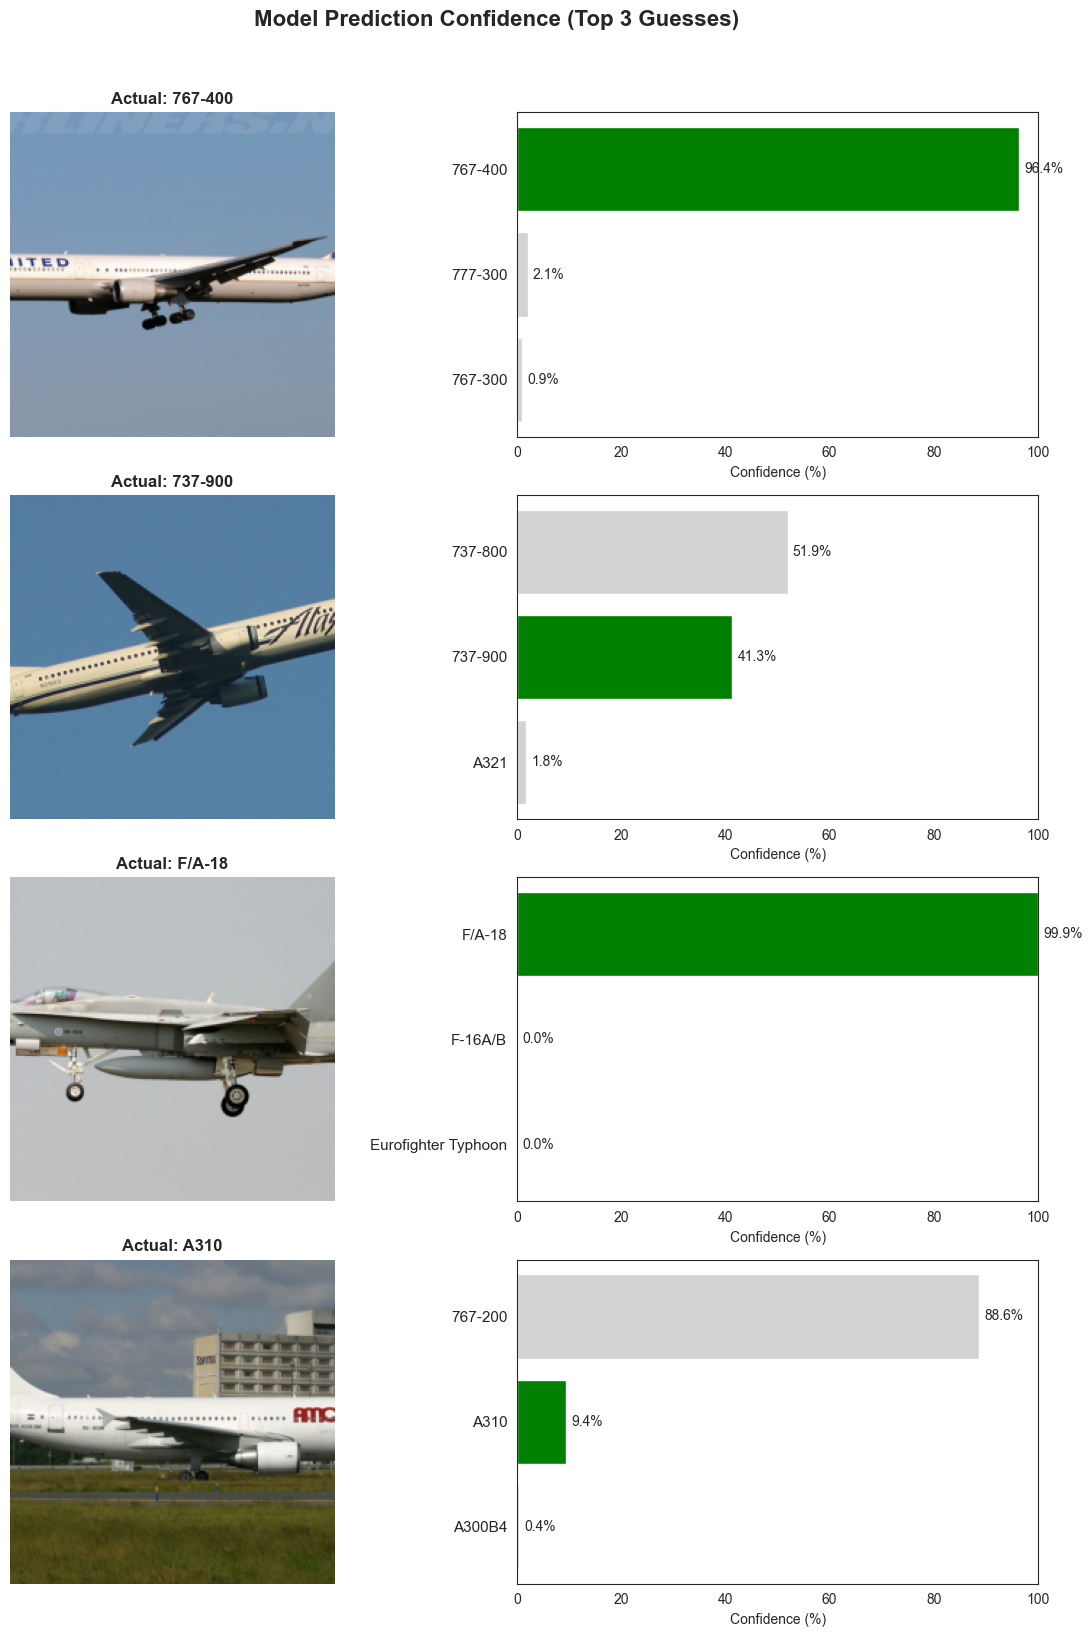

In [8]:
import torch.nn.functional as F

print("Generating Professional Confidence Grid...")

# Grab one random batch of 4 images from the test set
model.eval()
vis_loader = torch.utils.data.DataLoader(test_set, batch_size=4, shuffle=True)
inputs, labels = next(iter(vis_loader))

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
fig.suptitle("Model Prediction Confidence (Top 3 Guesses)", fontsize=16, fontweight='bold', y=1.02)

with torch.no_grad():
    inputs = inputs.to(device)
    outputs = model(inputs)
    # Convert raw output numbers into percentages (0 to 1)
    probabilities = F.softmax(outputs, dim=1)

for i in range(4):
    img_tensor = inputs[i]
    true_label = labels[i].item()
    
    # Get the top 3 highest percentages and their class indexes
    top3_probs, top3_indices = torch.topk(probabilities[i], 3)
    
    # De-normalize image for viewing
    img_np = img_tensor.cpu().numpy().transpose((1, 2, 0))
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    
    # 1. Plot the Image (Left Column)
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Actual: {test_set.classes[true_label]}", fontsize=12, fontweight='bold')
    axes[i, 0].axis('off')
    
    # 2. Plot the Bar Chart (Right Column)
    probs_list = top3_probs.cpu().numpy() * 100 # Convert to actual percentage
    class_names = [test_set.classes[idx.item()] for idx in top3_indices]
    
    # Color the bars: Green if it's the correct answer, Gray if it's a wrong guess
    colors = ['green' if name == test_set.classes[true_label] else 'lightgray' for name in class_names]
    
    y_pos = np.arange(len(class_names))
    axes[i, 1].barh(y_pos, probs_list, align='center', color=colors)
    axes[i, 1].set_yticks(y_pos)
    axes[i, 1].set_yticklabels(class_names, fontsize=11)
    axes[i, 1].invert_yaxis()  # Put the #1 guess at the top
    axes[i, 1].set_xlabel('Confidence (%)')
    axes[i, 1].set_xlim(0, 100)
    
    # Add the percentage numbers to the end of the bars
    for index, value in enumerate(probs_list):
        axes[i, 1].text(value + 1, index, f"{value:.1f}%", va='center')

plt.tight_layout()
plt.savefig('results/confidence_grid.png', dpi=300, bbox_inches='tight')
plt.show()